# Final Project

- For my final project, I am setting out to see what made Man City, the champions, win the English Premier League in the 2020-2021 season. Did they win just because of circumstances? Was it because they scored the most and conceded the least? Was it because they had the best player? Let's go find out.

- I will be using some CSV files. The first CSV file is an in-depth dataset that holds all the statistics per game as well as the results of every match from the 2020-2021 season. My other CSV has all the player season stats for each player in the league, including goals, assists, passing, expected goals (xG), and cards.

- In addition to these CSV files, I will be using an HTML file with Beautiful Soup to look at more statistics and iterate through semi-structured data from the Wikipedia page of the season.


# CSV #1 
## Score Table + Teams Goal Scored

With this CSV above, it has all the scores, team names, goals for, goals against, and many more statistics we can use for the 2020 - 2021 season. First, I want to set out and try to make my own score table of the league and put all the overall statistics on it. To do this, I will have to use pandas and numpy to do these calculations. 

1. Pandas is important because it provides the data frame for this whole spreadsheet. It also cleans the CSV file into a clean, labeled, and tabular structure.
2. Numpy is for calculating all the things that Pandas has made. This also makes it so that we can do calculations on the whole columns of the data rather than doing it every time.

Used this website to help with Numpy and was overall more fascinated with how to use it: https://www.datacamp.com/cheat-sheet/numpy-cheat-sheet-data-analysis-in-python


Used this website for pandas https://pandas.pydata.org/docs/user_guide/index.html

In [1]:
import csv

# Open the CSV file
file = "2020-2021.csv"

# Open and read the file
myFile = open(file, "r")
csvReader = csv.reader(myFile)
header = next(csvReader)  # Read the first row (column headers)
print("Header row:")
print(header)

Header row:
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA']


In [3]:
import pandas as pd
import numpy as np

def calculate_stats(df, team_col, goals_for_col, goals_against_col):
    
    # Determine the match outcome based on goal difference
    goal_diff = df[goals_for_col] - df[goals_against_col]

    # Calculate Wins (W), Draws (D), Losses (L) using numpy.where
    df['W'] = np.where(goal_diff > 0, 1, 0)
    df['D'] = np.where(goal_diff == 0, 1, 0)
    df['L'] = np.where(goal_diff < 0, 1, 0)

    # Calculate Points (3 for Win, 1 for Draw, 0 for Loss)
    df['P'] = df['W'] * 3 + df['D'] * 1

    # Rename goals columns for standard aggregation
    df['GF'] = df[goals_for_col] # Goals For
    df['GA'] = df[goals_against_col] # Goals Against

    # Group by team and sum the statistics
    stats = df.groupby(team_col).agg(
        GP=(team_col, 'size'), # Games Played
        W=('W', 'sum'),
        D=('D', 'sum'),
        L=('L', 'sum'),
        GF=('GF', 'sum'),
        GA=('GA', 'sum'),
        P=('P', 'sum')
    ).reset_index().rename(columns={team_col: 'Team'}).set_index('Team')

    return stats

def generate_points_table(csv_filepath):
    df = pd.read_csv(csv_filepath, usecols=['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'])

    # Home team is the 'goals_for' and away team is the 'goals_against'
    home_stats = calculate_stats(
        df[['HomeTeam', 'FTHG', 'FTAG']].copy(),
        'HomeTeam', 'FTHG', 'FTAG'
    )

    # Away team's goals (FTAG) are 'goals_for', and home team's goals (FTHG) are 'goals_against'
    away_stats = calculate_stats(
        df[['AwayTeam', 'FTAG', 'FTHG']].copy(),
        'AwayTeam', 'FTAG', 'FTHG'
    )

    # Combine stats for all teams (using .add for summation of common columns)
    final_table = home_stats.add(away_stats, fill_value=0)

    final_table['GD'] = final_table['GF'] - final_table['GA'] # Calculate Goal Difference
    final_table = final_table.reset_index()

    # Sort the table based on the standard criteria (Points, then GD, then GF)
    final_table = final_table.sort_values(
        by=['P', 'GD', 'GF'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

# Found this section looking up how to sort my table values on google through pandas and pythons. 
# Found it with this link: https://realpython.com/pandas-sort-python/

    
    # Add Position (Rank) and re-index starting from 1
    final_table.index = np.arange(1, len(final_table) + 1)
    final_table = final_table.reset_index().rename(columns={'index': 'Pos'})

    final_columns = ['Pos', 'Team', 'GP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'P']

    return final_table[final_columns]

csv_filename = '2020-2021.csv'
points_table = generate_points_table(csv_filename)
print(f"--- Soccer Final Points Table from {csv_filename} ---")
print(points_table.to_markdown(index=False))

--- Soccer Final Points Table from 2020-2021.csv ---
|   Pos | Team             |   GP |   W |   D |   L |   GF |   GA |   GD |   P |
|------:|:-----------------|-----:|----:|----:|----:|-----:|-----:|-----:|----:|
|     1 | Man City         |   38 |  27 |   5 |   6 |   83 |   32 |   51 |  86 |
|     2 | Man United       |   38 |  21 |  11 |   6 |   73 |   44 |   29 |  74 |
|     3 | Liverpool        |   38 |  20 |   9 |   9 |   68 |   42 |   26 |  69 |
|     4 | Chelsea          |   38 |  19 |  10 |   9 |   58 |   36 |   22 |  67 |
|     5 | Leicester        |   38 |  20 |   6 |  12 |   68 |   50 |   18 |  66 |
|     6 | West Ham         |   38 |  19 |   8 |  11 |   62 |   47 |   15 |  65 |
|     7 | Tottenham        |   38 |  18 |   8 |  12 |   68 |   45 |   23 |  62 |
|     8 | Arsenal          |   38 |  18 |   7 |  13 |   55 |   39 |   16 |  61 |
|     9 | Leeds            |   38 |  18 |   5 |  15 |   62 |   54 |    8 |  59 |
|    10 | Everton          |   38 |  17 |   8 |  13 |   

With this table, we can see some clear correlations that created the opportunity for **Man City** to win the league. They are tied for the fewest losses in the league and have also had the most wins in the season. Now that is very self-explanatory for the common person, but seeing these facts just shows what the recipe is to win the league. Win the most, and lose the least.

## Goals Scored


After seeing the number of goals scored across the whole league, I wanted to see how it compared to the other teams in the league. So let's create a bar chart to see what the difference is. 

- Used this to help make graph: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

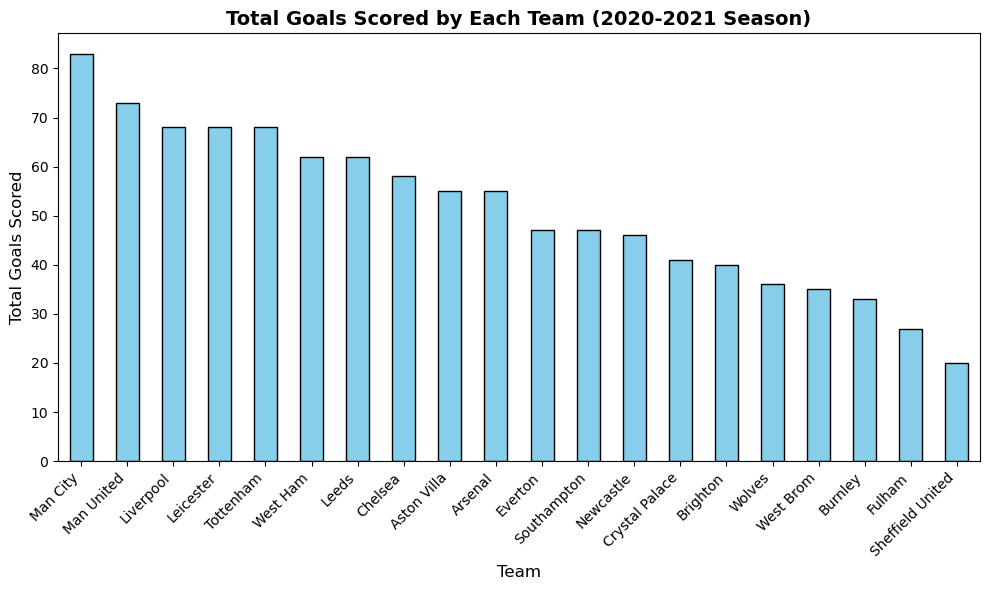

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def generate_goals_bar_chart(csv_filepath):

    df = pd.read_csv(csv_filepath, usecols=['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'])

    home_goals = df[['HomeTeam', 'FTHG']].copy()
    home_goals.columns = ['Team', 'Goals'] # Rename columns to 'Team' and 'Goals'
    
    away_goals = df[['AwayTeam', 'FTAG']].copy()
    away_goals.columns = ['Team', 'Goals'] # Rename columns to 'Team' and 'Goals'
    

    # Put all rows together (home goals and away goals)
    all_goals = pd.concat([home_goals, away_goals]) # cancat adds two data frames together, which we made above
    
    # Group by the 'Team' name and sum all the 'Goals'
    total_goals = all_goals.groupby('Team')['Goals'].sum()
    
    # Sort the results from highest goals scored to lowest
    total_goals_sorted = total_goals.sort_values(ascending=False)
    
    # Create the figure (window) and the axes (the chart area)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # The team names are the index (x-axis), and the goal counts are the values (y-axis)
    total_goals_sorted.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    
    
    ax.set_title('Total Goals Scored by Each Team (2020-2021 Season)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Team', fontsize=12)
    ax.set_ylabel('Total Goals Scored', fontsize=12)
    
    # Rotate the x-axis labels so they don't overlap
    plt.xticks(rotation=45, ha='right')
    
    # Add a tight layout to prevent labels from being cut off
    plt.tight_layout()
    
    # Save the chart to a file
    chart_filename = 'goals_scored_bar_chart.png'


csv_filename = '2020-2021.csv'
generate_goals_bar_chart(csv_filename)

From the bar chart above, you can see that the teams that score the most goals are most likely to be at the top of the table. With **Man City** having scored the most goals as well as winning the league, there is a clear correlation between the two. With the most goals scored, this proves that **Man City** had the best Attack this season. 

# Best Players

With this CSV, we are going to check how much the Manchester City players contributed compared to the other players in the league. Do they have more or less? 

First, we have to clean the CSV to make sure that we have all the correct names. To do this, I opened the CSV in Excel and had to manually make sure every name was an actual name and not some characters that looked like names.  

![Before and after cleaning player names in Excel](Before-After-Edit.png)


Now that we have it edited, let's make a table comparing the best player in that statistical category for a Man City player vs the best player in the league for that statistic

In [118]:
import pandas as pd

df = pd.read_csv('EPL_20_21_Edited_2.csv')


class Player: # make is so we can sort by their names and what club they play for
    def __init__(self, row):
        self.name = row["Name"]
        self.club = row["Club"]
        self.stats = row  # store the entire row for flexible access

    def get(self, stat):
        return self.stats[stat]

players = [Player(row) for _, row in df.iterrows()] #iterrow tells pandas to loop through the dataframe row by row

# Filtering for Manchester City players
mc_players = [p for p in players if p.club.lower() in ["man city", "manchester city"]] 

# Identify numeric stat columns
numeric_stats = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
#This line of code selects and returns a list of column names from the DataFrame (`df`) 
# that contain only numeric data types (specifically 64-bit integers and standard floats).


remove_cols = ["Age", "Matches", "Starts", "Mins"] # Remove non-performance columns that we don't need
numeric_stats = [s for s in numeric_stats if s not in remove_cols] # set which columns are stats so we can use them


results = []

for stat in numeric_stats:
    # Best Man City player
    best_mc = max(mc_players, key=lambda p: p.get(stat))
# Finds the single player dictionary in the list mc_players that has the maximum value for the statistic specified by the stat variable.
    # Best overall league player
    best_all = max(players, key=lambda p: p.get(stat))
# Finds the single player dictionary in the list of players that has the maximum value for the statistic specified by the stat variable.
    results.append({
        "Stat": stat,
        "Best Man City Player": best_mc.name,
        "MC Value": best_mc.get(stat),
        "Best League Player": best_all.name,
        "League Value": best_all.get(stat)
    })

comparison_df = pd.DataFrame(results)

comparison_df


,Stat,Best Man City Player,MC Value,Best League Player,League Value
0,Goals,Ilkay Gündogan,13.00,Harry Kane,23.00
1,Assists,Kevin De Bruyne,12.00,Harry Kane,14.00
2,Passes_Attempted,Rodri,2728.00,Andrew Robertson,3214.00
3,Perc_Passes_Completed,John Stones,94.30,Odion Ighalo,100.00
4,Penalty_Goals,Kevin De Bruyne,2.00,Bruno Fernandes,9.00
5,Penalty_Attempted,Kevin De Bruyne,3.00,Bruno Fernandes,10.00
6,xG,Sergio Aguero,0.54,Antwoine Hackford,1.16
7,xA,Kevin De Bruyne,0.46,Theo Corbeanu,0.90
8,Yellow_Cards,Rodri,6.00,John McGinn,12.00
9,Red_Cards,Joao Cancelo,1.00,Lewis Dunk,2.00


Looking at these stats, you can see that Man City doesn't rank highest in the stats of every category, yet when you look deeper into the numbers, you can see that key players like Kevin De Bruyne and Rodri pop up in multiple categories. While never topping the charts, from what we can see, they can be identified as key players in the Man City squad. Additionally, we can see that they didn't have the "best player in the league." Proving that you don't need the "best player in the league" in order to win.

However, this chart brings up the question of how Man City can win the league without topping the charts in any of these important statistics. Let's take a look at the goal scorers for this team with Matplotlib.

- Used this as source: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

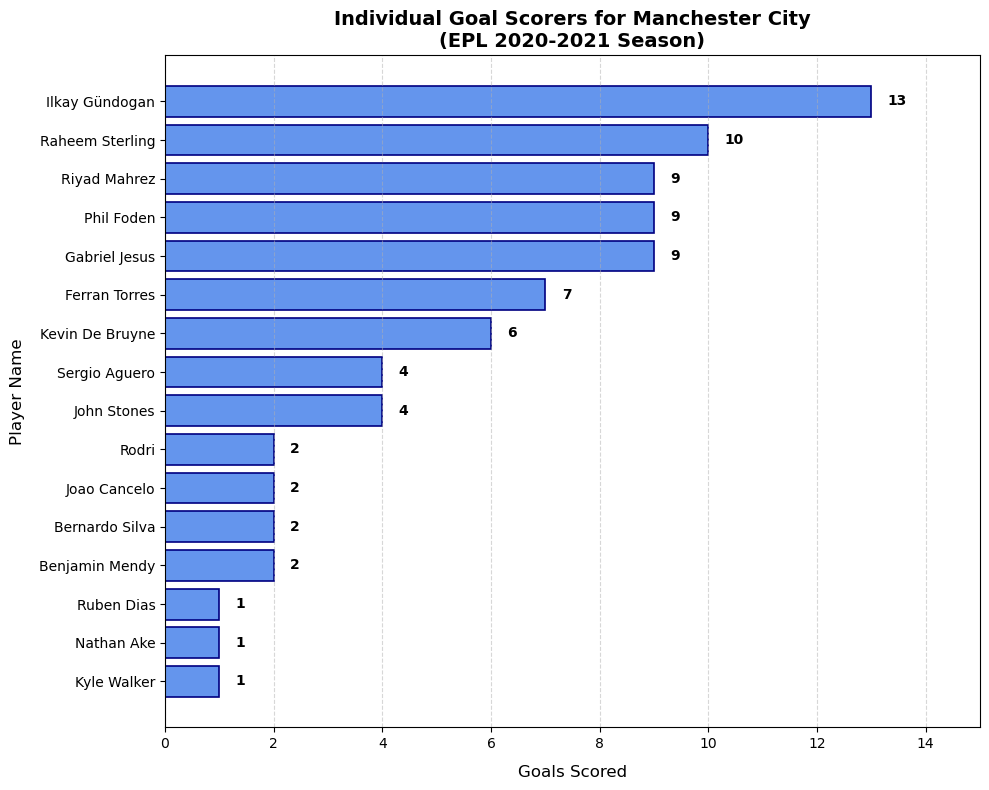

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('EPL_20_21_Edited_2.csv')

# Filter the DataFrame for the correct club name: 'Manchester City'
man_city_df = df[df['Club'] == 'Manchester City']

# Group by player name and goals 
goals_by_player = man_city_df.groupby('Name')['Goals'].sum().reset_index()

# Filter out players with 0 goals
goals_by_player = goals_by_player[goals_by_player['Goals'] > 0]

# Sort the data by goals scored in ascending order 
goals_by_player = goals_by_player.sort_values(by='Goals', ascending=True)

labels = goals_by_player['Name']
sizes = goals_by_player['Goals']


plt.figure(figsize=(10, 8))

# Create the horizontal bar chart
bars = plt.barh(labels, sizes, color='cornflowerblue', edgecolor='navy', linewidth=1.2)

# Add goal counts (data labels) to the bars
for bar in bars:
    plt.text(
        # Position the text slightly to the right of the bar end
        bar.get_width() + 0.3,
        # Center the text vertically
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        ha='left',      # Horizontal alignment
        va='center',    # Vertical alignment
        color='black',
        fontsize=10,
        fontweight='bold'
    )

# Set chart labels and title
plt.xlabel('Goals Scored', fontsize=12, labelpad=10)
plt.ylabel('Player Name', fontsize=12, labelpad=10)
plt.title(
    'Individual Goal Scorers for Manchester City\n(EPL 2020-2021 Season)',
    fontsize=14,
    fontweight='bold'
)

# Customize the grid and limits
plt.xlim(0, sizes.max() + 2) # Extend X-axis limit slightly past the highest value
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()


plt.show()


Adding all these goals together, we get a total of 82 goals across the whole team. But when looking above, we see that **MAN CITY** had 83 goals total for the whole year. This means that there was an own goal (A goal scored by the defending team into their own net) during the season. 

Analytical wise, this chart shows that the full squad contributed to the championship season. They didn't have a heavy load on a specific person to score the goals but was a group effort. This is important as if one person gets injured they will still have goal scorers in the team to create chances and make it so they can still win the games. 

# HTML

- Using this wikipedia page about the 2020-2021 Premier League season, we are going to use Beautiful Soup to iterate through the semi-data structures that we have on the page and use those to do some analysis about it.
  

In [11]:
from bs4 import BeautifulSoup

file_name = "2020–21-EPL.html"

with open(file_name, 'r', encoding='utf-8') as file:
    html_content = file.read()

soup = BeautifulSoup(html_content, 'html.parser')

# The full page source is thousands of lines long, so only print the first 40
page_lines = str(soup).split("\n")
print("\n".join(page_lines[:40]))
print(f"\n... showing 40 of {len(page_lines):,} lines")

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>2020–21 Premier League - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled v

Now that we have the HTML imported, we want to find the data structures that we want. First, I am going to iterate through the clean sheet data table and make a visual about it. 

In [26]:
import pandas as pd

file_name = "2020–21-EPL.html"
search_term = 'clean sheets'

try:
    list_of_dfs = pd.read_html(file_name)    
    clean_sheets_df = next(
        (df for df in list_of_dfs if any(search_term in str(col).lower() for col in df.columns)),
        None
    )# Uses the next function to search through the list of dfs in the HTML and find the clean sheets one 
#(Did this with Ben's Help in Office Hours)
except ValueError:
    clean_sheets_df = None

print("\n--- Clean Sheets Data Frame ---")
print(clean_sheets_df)



--- Clean Sheets Data Frame ---
    Rank             Player                     Club  Clean sheets
0      1            Ederson          Manchester City            19
1      2      Édouard Mendy                  Chelsea            16
2      3  Emiliano Martínez              Aston Villa            15
3      4        Hugo Lloris        Tottenham Hotspur            12
4      5         Bernd Leno                  Arsenal            11
5      5      Illan Meslier             Leeds United            11
6      5          Nick Pope                  Burnley            11
7      5  Kasper Schmeichel           Leicester City            11
8      9            Alisson                Liverpool            10
9      9   Łukasz Fabiański          West Ham United            10
10     9       Rui Patrício  Wolverhampton Wanderers            10
11     9    Jordan Pickford                  Everton            10
12     9     Robert Sánchez   Brighton & Hove Albion            10


Clean sheets are when a team doesn't concede a goal during the game. This can be visualized by how many times the scores were 3-0 at home or when the team was away 0-3. This stat, although it shows the goalkeeper's name and always awards the goalkeeper who wins the award a Golden Glove, is more of a team stat, specifically highlighting the defensive unit and the goalkeeper working together. This stat is important because scoring goals is the way to win the game, and if you can stop other teams from scoring, then you are in a much better place to win the league and overall be the best team you can be that year. 

Having the best defense in the league helps immensely in your title charge. 

In [15]:
print(list_of_dfs[11])

  PFA Team of the Year[145]        PFA Team of the Year[145].1  \
0                Goalkeeper          Ederson (Manchester City)   
1                 Defenders     João Cancelo (Manchester City)   
2               Midfielders  Kevin De Bruyne (Manchester City)   
3                  Forwards          Mohamed Salah (Liverpool)   
4                       NaN                                NaN   

         PFA Team of the Year[145].2        PFA Team of the Year[145].3  \
0          Ederson (Manchester City)          Ederson (Manchester City)   
1     João Cancelo (Manchester City)     João Cancelo (Manchester City)   
2  Kevin De Bruyne (Manchester City)  Kevin De Bruyne (Manchester City)   
3          Mohamed Salah (Liverpool)          Mohamed Salah (Liverpool)   
4                                NaN                                NaN   

         PFA Team of the Year[145].4       PFA Team of the Year[145].5  \
0          Ederson (Manchester City)         Ederson (Manchester City)   
1   

In [49]:
import pandas as pd

data = {
    'Player Name': [
        'Bruno Fernandes', 'Ederson', 'Harry Kane', 'John Stones', 
        'João Cancelo', 'Kevin De Bruyne', 'Luke Shaw', 'Mohamed Salah', 
        'Rúben Dias', 'Son Heung-min', 'İlkay Gündoğan'
    ],
    'Club': [
        'Manchester United', 'Manchester City', 'Tottenham Hotspur', 'Manchester City', 
        'Manchester City', 'Manchester City', 'Manchester United', 'Liverpool', 
        'Manchester City', 'Tottenham Hotspur', 'Manchester City'
    ]
}
df_final = pd.DataFrame(data).sort_values(by='Player Name').reset_index(drop=True)


print("## ⚽ PFA Team of the Year - Unique Players\n")

for index, row in df_final.iterrows():
    output_string = f" {row['Player Name']} ({row['Club']})"
    print(output_string)

## ⚽ PFA Team of the Year - Unique Players

 Bruno Fernandes (Manchester United)
 Ederson (Manchester City)
 Harry Kane (Tottenham Hotspur)
 John Stones (Manchester City)
 João Cancelo (Manchester City)
 Kevin De Bruyne (Manchester City)
 Luke Shaw (Manchester United)
 Mohamed Salah (Liverpool)
 Rúben Dias (Manchester City)
 Son Heung-min (Tottenham Hotspur)
 İlkay Gündoğan (Manchester City)


In [29]:
print(list_of_dfs[10])

                                       Award                Winner  \
0       Premier League Manager of the Season    Pep Guardiola[138]   
1        Premier League Player of the Season       Rúben Dias[139]   
2  Premier League Young Player of the Season       Phil Foden[140]   
3          Premier League Goal of the Season      Erik Lamela[141]   
4            PFA Players' Player of the Year  Kevin De Bruyne[142]   
5               PFA Young Player of the Year       Phil Foden[142]   
6                 FWA Footballer of the Year       Rúben Dias[143]   
7               PFA Fans' Player of the Year    Mohamed Salah[144]   

                Club  
0    Manchester City  
1    Manchester City  
2    Manchester City  
3  Tottenham Hotspur  
4    Manchester City  
5    Manchester City  
6    Manchester City  
7          Liverpool  


To give some background information, the PFA is the Professional Footballers' Association, and specifically in this sense, is the trade union for professional footballers in England and Wales. This federation gives professional footballers a chance to voice their opinions and support each other. In 1974, the PFA created awards that are given out every year using a now modernized online anonymous ballot system. This gives a platform for fellow footballers to show support to the players that they play against and award them for a good performance. 

- https://en.wikipedia.org/wiki/Professional_Footballers%27_Association

Going off this year's awards, we can see that a lot of Manchester City players are being recognized as key players and staff during the season. We have the best manager of the season, being from Man City, while also the best player and youth player, also recognized by the association. This shows that there is a clear distinction and support of Man City players being the best that year after winning the title. 

Now, let's make a pie chart that looks at which teams got the most awards.
- https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

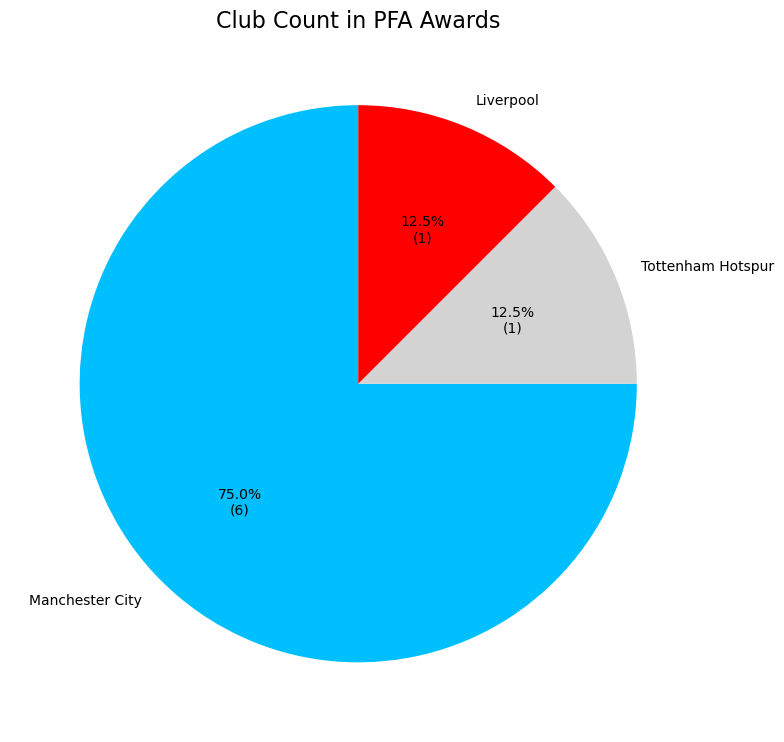

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Awards_Clubs = [
    'Manchester City',
    'Manchester City',
    'Manchester City',
    'Tottenham Hotspur',
    'Manchester City',
    'Manchester City',
    'Manchester City',
    'Liverpool'
]

PFA_Clubs = [
    'Manchester United',
    'Manchester City',
    'Tottenham Hotspur',
    'Manchester City',
    'Manchester City',
    'Manchester City',
    'Manchester United',
    'Liverpool',
    'Manchester City',
    'Tottenham Hotspur',
    'Manchester City'
]

colors = { 'Manchester United': 'darkorange' ,
          'Manchester City' : 'deepskyblue' ,
          'Tottenham Hotspur': 'lightgray',
          'Liverpool' : 'red'}

def func(pct, allvalues):
    absolute = int(pct/100.*sum(allvalues))
    return "{:.1f}%\n({:d})".format(pct, absolute) #String formating line

# Made this function in Ben's Office Hours, pct = percentage to one percentage (.1f), followed by printing out a second line after it to show 
# the raw (absolute) data.

awards_counts = pd.Series(Awards_Clubs).value_counts()
pfa_counts = pd.Series(PFA_Clubs).value_counts()


plt.figure(figsize=(8, 8))
plt.title('Club Count in PFA Awards', fontsize=16)

plt.pie(awards_counts, 
        labels=awards_counts.index, 
        colors=[colors[key] for key in awards_counts.index],
        autopct=lambda pct: func(pct, awards_counts),
        startangle=90, 
        textprops={'fontsize': 10})

plt.tight_layout()
plt.savefig('Awards_Clubs_Pie_Chart.png')
plt.show()
plt.close()

In [101]:
print(awards_counts)

Manchester City      6
Tottenham Hotspur    1
Liverpool            1
Name: count, dtype: int64


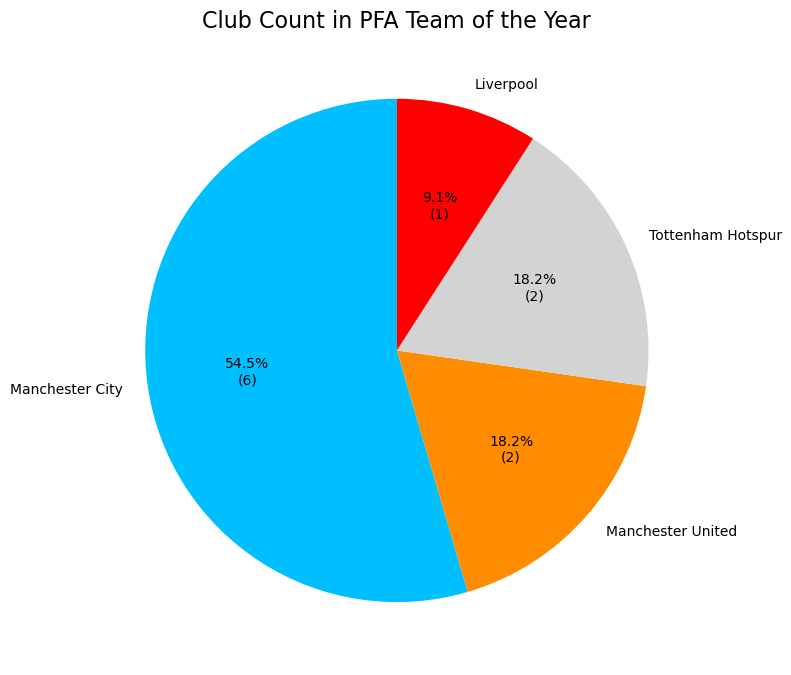

In [111]:
plt.figure(figsize=(8, 8))
plt.title('Club Count in PFA Team of the Year', fontsize=16)

plt.pie(pfa_counts, 
        labels=pfa_counts.index,
        colors=[colors[key] for key in pfa_counts.index],
        autopct=lambda pct: func(pct, pfa_counts),
        startangle=90, 
        textprops={'fontsize': 10})

plt.tight_layout()
plt.savefig('PFA_Clubs_Pie_Chart.png')
plt.show()
plt.close()

Going off these graphs, you can see that the colleagues of the Manchester City players in the league are voting for them. This shows that they have clear recognition from their colleagues and further reiterates their appreciated talents in the league. While it might not show that they are the unanimous best player in the league, this does show that they have great talent and skills that justify them winning the league. 

# Conclusion

After looking through this data, we can see that Manchester City had a lot of redeeming traits that led them to win the title, from having the best defense by conceding the least amount of goals, to the best offense by scoring the most goals, to being recognized by fellow players in having the best players and staff in the league. These 3 main features just show that Man City were firing on all cylinders to win the 2020-2021 English Premier League Season 

To talk about what I learned during this project, I learned a lot about Matplotlib and how to graph with it. Going into this project, I didn't fully understand what it really took to make a graph, as I would usually just copy what Professor Proft would write on the board. However, now that I have gone through this project, I can say that I know a lot more about how to code for Matplotlib in Jupyter notebooks. 